# Brain Tumor MRI — Exploratory Data Analysis

**Dataset:** [LGG MRI Segmentation (Kaggle)](https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation) — 110 patients with lower-grade gliomas, drawn from *The Cancer Imaging Archive (TCIA)* and *The Cancer Genome Atlas (TCGA)*.

---

## Medical primer 

The dataset sits at the intersection of *neuro-oncology*, *radiology*, and *machine learning*. A few terms recur throughout the notebook:

| Term | Definition | 
|---|---|
| **Glioma** | A tumour that arises from *glial cells* — the cells that support and insulate neurons in the brain and spinal cord. |
| **LGG (Lower-Grade Glioma)** | WHO grades **II** and **III** gliomas. Slower-growing than glioblastomas (grade IV), but still life-limiting. |
| **WHO grade** | The World Health Organisation's 4-tier malignancy scale for CNS tumours, from I (benign) to IV (most aggressive). |
| **MRI (Magnetic Resonance Imaging)** | Non-ionising imaging modality that uses strong magnetic fields and radio waves to image soft tissue. |
| **MR sequence** | A specific way of acquiring an MRI image (different timings → different tissue contrasts). |
| **FLAIR** | *Fluid-Attenuated Inversion Recovery*. A T2-weighted sequence with the cerebrospinal-fluid signal suppressed; lesions and oedema appear bright. **The reference channel for tumour delineation in this dataset.** |
| **Pre-contrast (T1)** | Baseline T1-weighted scan acquired *before* injecting a gadolinium-based contrast agent. Anatomical reference. |
| **Post-contrast (T1+Gd)** | Same T1 sequence acquired *after* contrast injection. Areas where the blood-brain barrier is broken (typical of high-grade tumours) appear bright. |
| **Axial slice** | A 2-D cross-section of the head taken parallel to the floor (top-down view). The native MRI volume is 3-D; we work with one axial slice at a time. |
| **Segmentation mask** | A binary image where each pixel is `1` if it belongs to the tumour / FLAIR abnormality and `0` otherwise. |
| **TCGA / TCIA** | *The Cancer Genome Atlas* (genomic) and *The Cancer Imaging Archive* (imaging) — public consortia that contributed this cohort. |
| **Genomic clusters** | Unsupervised groupings of patients using molecular profiles (RNA-Seq, methylation, miRNA, copy-number, RPPA, oncosign, COC). They correlate with prognosis. |


## 1. Setup

We work entirely with the *raw* dataset under `data/raw/kaggle_3m/`. All cells are deterministic (`SEED = 42`) so the figures are reproducible.

In [1]:
from __future__ import annotations

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path('../data/raw/kaggle_3m')
assert DATA_DIR.exists(), f'Dataset not found at {DATA_DIR}'

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 110

PALETTE = sns.color_palette('viridis', as_cmap=False)
BRAND = {'pre': '#4C72B0', 'flair': '#DD8452', 'post': '#55A467', 'mask': '#C44E52'}

## 2. What's actually on disk?

Each patient lives in a folder named `TCGA_<institution>_<patient-id>_<acquisition-date>`. Inside, every axial slice is stored as a pair of 256×256 TIFF files — one **MRI image** (3-channel) and one **mask** (single channel, binary).

```
data/raw/kaggle_3m/
├── data.csv                          ← clinical & genomic metadata
├── TCGA_CS_4941_19960909/
│   ├── TCGA_CS_4941_19960909_1.tif       ← slice 1, MRI (256×256×3, uint8)
│   ├── TCGA_CS_4941_19960909_1_mask.tif  ← slice 1, mask (256×256,  uint8)
│   └── ... (more slices)
└── ...
```

**The 3 channels of every image** correspond to three MR sequences:

1. **Channel 0 → pre-contrast (T1)** — anatomical baseline.
2. **Channel 1 → FLAIR** — the *primary* signal for tumour delineation (this is the channel the radiologist actually annotated).
3. **Channel 2 → post-contrast (T1+Gd)** — highlights blood-brain-barrier breakdown.

> Per the dataset README: for **9 cases** the post-contrast sequence is missing, and for **6 cases** the pre-contrast is missing. The missing channel is *replaced by FLAIR* so that every image is technically 3-channel. We'll detect this duplication empirically below.

In [2]:
patient_dirs = sorted([p for p in DATA_DIR.iterdir() if p.is_dir() and p.name.startswith('TCGA_')])
print(f'Number of patient folders: {len(patient_dirs)}')
print('First 3 patient IDs       :', [p.name for p in patient_dirs[:3]])

# Build a slice-level index. One row per slice = (patient, slice_number, image_path, mask_path)
rows = []
for pdir in patient_dirs:
    files = sorted(pdir.iterdir())
    masks = {f.name: f for f in files if f.name.endswith('_mask.tif')}
    images = [f for f in files if f.name.endswith('.tif') and not f.name.endswith('_mask.tif')]
    for img in images:
        m = re.match(r'(.+)_(\d+)\.tif$', img.name)
        if m is None:
            continue
        stem, slice_num = m.group(1), int(m.group(2))
        mask_name = f'{stem}_{slice_num}_mask.tif'
        if mask_name in masks:
            rows.append({
                'patient_id': pdir.name,
                'slice_num': slice_num,
                'image_path': str(img),
                'mask_path': str(masks[mask_name]),
            })

slices = pd.DataFrame(rows).sort_values(['patient_id', 'slice_num']).reset_index(drop=True)
print(f'Number of slices total    : {len(slices)}')
slices.head(3)

Number of patient folders: 110
First 3 patient IDs       : ['TCGA_CS_4941_19960909', 'TCGA_CS_4942_19970222', 'TCGA_CS_4943_20000902']
Number of slices total    : 3929


,patient_id,slice_num,image_path,mask_path
0,TCGA_CS_4941_19960909,1,../data/raw/kaggle_3m/TCGA_CS_4941_19960909/TC...,../data/raw/kaggle_3m/TCGA_CS_4941_19960909/TC...
1,TCGA_CS_4941_19960909,2,../data/raw/kaggle_3m/TCGA_CS_4941_19960909/TC...,../data/raw/kaggle_3m/TCGA_CS_4941_19960909/TC...
2,TCGA_CS_4941_19960909,3,../data/raw/kaggle_3m/TCGA_CS_4941_19960909/TC...,../data/raw/kaggle_3m/TCGA_CS_4941_19960909/TC...


### 2.1 Building a quantitative summary

Before we start plotting, we walk every mask once to compute its tumour area (count of non-zero pixels) and we sample every image once to compute per-channel statistics. This is the heaviest cell in the notebook (~1 minute) — every later analysis re-uses these cached features.

In [3]:
def mask_area(path: str) -> int:
    return int((np.array(Image.open(path)) > 0).sum())

def image_stats(path: str) -> dict:
    arr = np.array(Image.open(path)).astype(np.float32)  # H, W, 3
    out = {}
    for c, name in enumerate(['pre', 'flair', 'post']):
        ch = arr[..., c]
        out[f'{name}_mean'] = float(ch.mean())
        out[f'{name}_std']  = float(ch.std())
        out[f'{name}_max']  = float(ch.max())
    # Detect duplicated FLAIR channel: if two channels are pixel-identical the patient has a missing sequence
    out['pre_eq_flair']  = bool(np.array_equal(arr[..., 0], arr[..., 1]))
    out['post_eq_flair'] = bool(np.array_equal(arr[..., 2], arr[..., 1]))
    return out

tqdm.pandas(desc='masks ')
slices['tumor_area'] = slices['mask_path'].progress_apply(mask_area)

tqdm.pandas(desc='images')
stats_df = pd.DataFrame(list(slices['image_path'].progress_apply(image_stats)))
slices = pd.concat([slices, stats_df], axis=1)
slices['has_tumor'] = slices['tumor_area'] > 0
print(slices[['patient_id', 'slice_num', 'tumor_area', 'has_tumor', 'flair_mean']].head())

masks :   0%|          | 0/3929 [00:00<?, ?it/s]

images:   0%|          | 0/3929 [00:00<?, ?it/s]

              patient_id  slice_num  tumor_area  has_tumor  flair_mean
0  TCGA_CS_4941_19960909          1           0      False   13.594635
1  TCGA_CS_4941_19960909          2           0      False   47.086563
2  TCGA_CS_4941_19960909          3           0      False   47.230469
3  TCGA_CS_4941_19960909          4           0      False   46.938293
4  TCGA_CS_4941_19960909          5           0      False   44.705811


## 3. Counting the cohort — *Viz 1 & 2*

**Why this matters.** Three numbers determine how aggressive our modelling can be: the number of patients (limits how rich a model we can train without overfitting), the number of slices (limits the effective batch budget), and the *positive rate* (how many slices actually contain a tumour). A heavy class imbalance demands weighted losses or oversampling later.

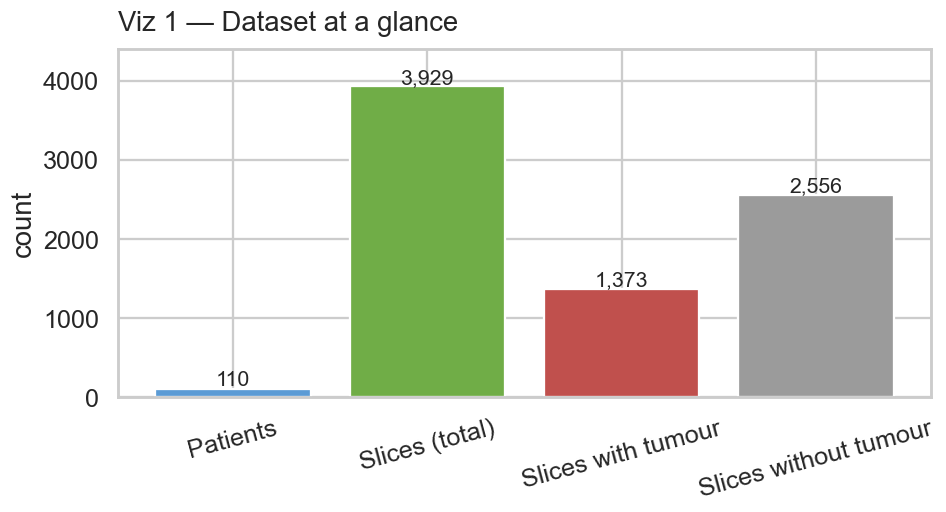

Positive slice rate: 34.9%


In [4]:
n_patients = slices['patient_id'].nunique()
n_slices = len(slices)
n_pos = int(slices['has_tumor'].sum())
n_neg = n_slices - n_pos

fig, ax = plt.subplots(figsize=(9, 5))
labels = ['Patients', 'Slices (total)', 'Slices with tumour', 'Slices without tumour']
values = [n_patients, n_slices, n_pos, n_neg]
colors = ['#5B9BD5', '#70AD47', '#C0504D', '#9B9B9B']
bars = ax.bar(labels, values, color=colors)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + max(values)*0.01, f'{v:,}', ha='center', fontsize=14)
ax.set_title('Viz 1 — Dataset at a glance', loc='left', pad=12)
ax.set_ylabel('count')
ax.set_ylim(0, max(values) * 1.12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(f'Positive slice rate: {n_pos / n_slices:.1%}')

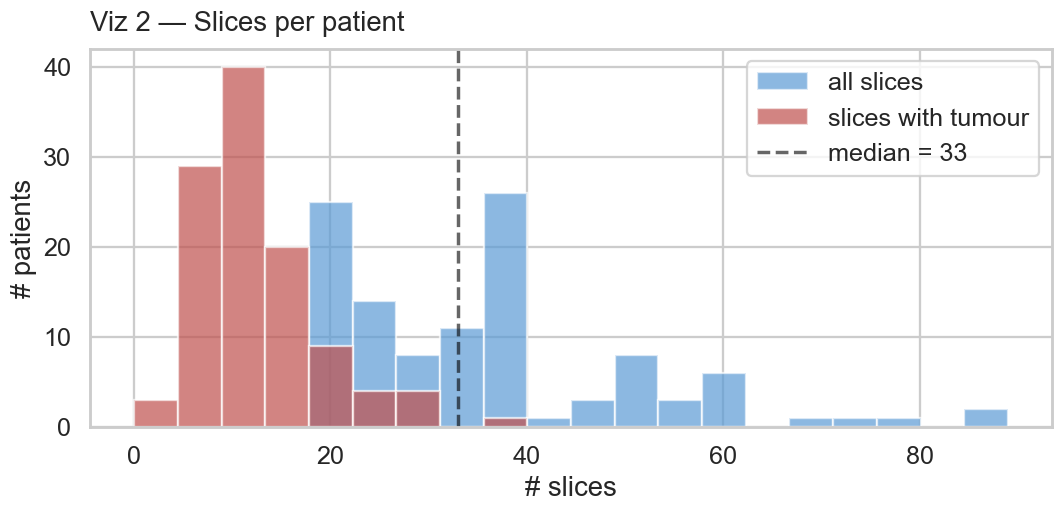

Slices per patient — describe:
count    110.0
mean      35.7
std       15.2
min       20.0
25%       23.2
50%       33.0
75%       39.5
max       88.0


In [5]:
slices_per_patient = slices.groupby('patient_id').size()
pos_per_patient = slices.groupby('patient_id')['has_tumor'].sum()

# Shared bin edges so the two histograms align on the same x-axis grid
bin_max = int(max(slices_per_patient.max(), pos_per_patient.max())) + 1
bins = np.linspace(0, bin_max, 21)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(slices_per_patient, bins=bins, color='#5B9BD5', edgecolor='white', alpha=0.7, label='all slices')
ax.hist(pos_per_patient,    bins=bins, color='#C0504D', edgecolor='white', alpha=0.7, label='slices with tumour')
ax.set_title('Viz 2 — Slices per patient', loc='left', pad=12)
ax.set_xlabel('# slices')
ax.set_ylabel('# patients')
ax.axvline(slices_per_patient.median(), ls='--', c='black', alpha=0.6, label=f'median = {int(slices_per_patient.median())}')
ax.legend()
plt.tight_layout()
plt.show()

print('Slices per patient — describe:')
print(slices_per_patient.describe().round(1).to_string())

**How to read this chart.** Two overlaid histograms, both indexed by *# slices per patient* (x-axis) against *# patients* (y-axis):

- 🟦 **all slices** — for each patient, the *total* number of axial slices in their MRI volume (i.e. how many cross-sections the radiologist actually acquired for that patient).
- 🟥 **slices with tumour** — of those slices, how many contain a non-empty tumour mask.

The red distribution is a strict subset of the blue one: only a portion of each volume actually intersects the lesion (the rest sit above or below it anatomically), so the positive count per patient is mechanically smaller than the total. That's why the red histogram sits to the left of the blue one — by construction, not by accident.

**What we observe.**

- **Total slices per patient is highly variable** — median ≈ **33**, ranging from ~15 up to >80. So MRI volumes are *not* uniform: a few patients have 3× more slices than others, which would bias any naive slice-level sampling scheme.
- **Positive-slice counts cluster much lower** — most patients fall in the 5–15 positive-slice range, with a peak near 10. Roughly a third of each volume hits the tumour, consistent with the slice-level positive rate seen in Viz 14 (~35%).
- **Long right tail on the blue distribution** — a handful of patients with 60–90 slices. These will dominate slice-level batches if we don't sample carefully.

**Implication for splits.** Each patient produces a *correlated cluster* of slices (consecutive slices look near-identical). Splitting by slice would let near-duplicates leak between train and val, inflating metrics. **We must split by patient** — this is later enforced as a unit test. The slice-count variance also argues for patient-balanced sampling during training, so longer volumes don't drown out shorter ones.

## 4. Who are the patients? — *Viz 3 → 9*

`data.csv` is the bridge between *images* and *biology*. Each row is one patient and carries 17 attributes. Some are demographic (age, gender, race), some are anatomical (laterality, location), some are pathological (histological grade, tumour tissue site), some are clinical (death within follow-up window), and the rest are *genomic clusters*.

**Decoding the categorical columns.** The dataset uses integer codes throughout. We map them to readable labels using the conventions of the TCGA-LGG cohort:

- `gender`: 1 = Male, 2 = Female
- `race`: 1 = White, 2 = Black/African-American, 3 = Asian, 4 = American Indian/Alaska Native
- `ethnicity`: 1 = Hispanic/Latino, 2 = Not Hispanic
- `histological_type`: 1 = Astrocytoma, 2 = Oligoastrocytoma, 3 = Oligodendroglioma
- `neoplasm_histologic_grade`: **1 = WHO Grade II, 2 = WHO Grade III** *(empirically verified against `death01` and age-at-diagnosis — see note below)*
- `laterality`: 1 = Left, 2 = Right, 3 = Midline
- `tumor_location`: 1 = Frontal, 2 = Temporal, 3 = Parietal, 4 = Occipital, 5 = Insula, ...
- `death01`: 0 = Alive at last follow-up, 1 = Deceased

> **Heads-up on the grade encoding.** The classical TCGA convention encodes histological grade as the WHO numeral itself (`2` for Grade II, `3` for Grade III). This particular CSV — repackaged by the Kaggle dataset author — uses **`1` and `2` instead**. We confirmed the direction by cross-checking against `death01`: code `2` has roughly twice the mortality of code `1` (34% vs. 14%) and is associated with older patients (median 50 vs. 43 years), which matches the known clinical trajectory of Grade III vs. Grade II. So `1 → Grade II`, `2 → Grade III`.

In [6]:
meta = pd.read_csv(DATA_DIR / 'data.csv')
print('rows:', len(meta), '| cols:', meta.shape[1])
print('columns:', list(meta.columns))
meta.head(3)

rows: 110 | cols: 18
columns: ['Patient', 'RNASeqCluster', 'MethylationCluster', 'miRNACluster', 'CNCluster', 'RPPACluster', 'OncosignCluster', 'COCCluster', 'histological_type', 'neoplasm_histologic_grade', 'tumor_tissue_site', 'laterality', 'tumor_location', 'gender', 'age_at_initial_pathologic', 'race', 'ethnicity', 'death01']


,Patient,RNASeqCluster,MethylationCluster,miRNACluster,CNCluster,RPPACluster,OncosignCluster,COCCluster,histological_type,neoplasm_histologic_grade,tumor_tissue_site,laterality,tumor_location,gender,age_at_initial_pathologic,race,ethnicity,death01
0,TCGA_CS_4941,2.0,4.0,2,2.0,NaN,3.0,2,1.0,2.0,1.0,3.0,2.0,2.0,67.0,3.0,2.0,1.0
1,TCGA_CS_4942,1.0,5.0,2,1.0,1.0,2.0,1,1.0,2.0,1.0,3.0,2.0,1.0,44.0,2.0,NaN,1.0
2,TCGA_CS_4943,1.0,5.0,2,1.0,2.0,2.0,1,1.0,2.0,1.0,1.0,2.0,2.0,37.0,3.0,NaN,0.0


In [7]:
MAPS = {
    'gender': {1: 'Male', 2: 'Female'},
    'race': {1: 'White', 2: 'Black', 3: 'Asian', 4: 'AmIndian/AKNative'},
    'ethnicity': {1: 'Hispanic/Latino', 2: 'Not Hispanic'},
    'histological_type': {1: 'Astrocytoma', 2: 'Oligoastrocytoma', 3: 'Oligodendroglioma'},
    # Grade is encoded 1 / 2 in this CSV (not 2 / 3 as the TCGA convention suggests).
    # Verified empirically against death01 + age: code 2 has ~2× the mortality and is older,
    # consistent with Grade III being more aggressive than Grade II.
    'neoplasm_histologic_grade': {1: 'Grade II', 2: 'Grade III'},
    'laterality': {1: 'Left', 2: 'Right', 3: 'Midline'},
    'tumor_location': {1: 'Frontal', 2: 'Temporal', 3: 'Parietal', 4: 'Occipital', 5: 'Insula'},
    'death01': {0: 'Alive', 1: 'Deceased'},
}
for col, m in MAPS.items():
    if col in meta.columns:
        meta[col + '_label'] = meta[col].map(m).fillna('Unknown')

# Patient-image join key (truncated patient code)
meta['short_id'] = meta['Patient'].str.replace('TCGA_', '', regex=False)
slices['short_id'] = slices['patient_id'].str.extract(r'TCGA_([A-Z0-9_]+)_\d{8}$')
meta.head(3)

,Patient,RNASeqCluster,MethylationCluster,miRNACluster,CNCluster,RPPACluster,OncosignCluster,COCCluster,histological_type,neoplasm_histologic_grade,...,death01,gender_label,race_label,ethnicity_label,histological_type_label,neoplasm_histologic_grade_label,laterality_label,tumor_location_label,death01_label,short_id
0,TCGA_CS_4941,2.0,4.0,2,2.0,NaN,3.0,2,1.0,2.0,...,1.0,Female,Asian,Not Hispanic,Astrocytoma,Grade III,Midline,Temporal,Deceased,CS_4941
1,TCGA_CS_4942,1.0,5.0,2,1.0,1.0,2.0,1,1.0,2.0,...,1.0,Male,Black,Unknown,Astrocytoma,Grade III,Midline,Temporal,Deceased,CS_4942
2,TCGA_CS_4943,1.0,5.0,2,1.0,2.0,2.0,1,1.0,2.0,...,0.0,Female,Asian,Unknown,Astrocytoma,Grade III,Left,Temporal,Alive,CS_4943


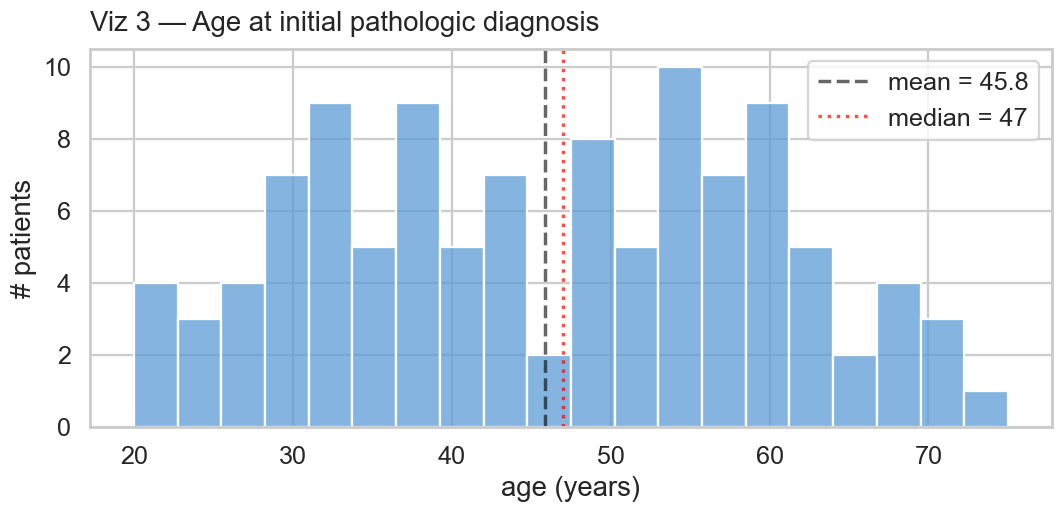

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=meta, x='age_at_initial_pathologic', bins=20, color='#5B9BD5', edgecolor='white', ax=ax)
ax.axvline(meta['age_at_initial_pathologic'].mean(), ls='--', c='black', alpha=0.6, label=f"mean = {meta['age_at_initial_pathologic'].mean():.1f}")
ax.axvline(meta['age_at_initial_pathologic'].median(), ls=':', c='red', alpha=0.7, label=f"median = {meta['age_at_initial_pathologic'].median():.0f}")
ax.set_title('Viz 3 — Age at initial pathologic diagnosis', loc='left', pad=12)
ax.set_xlabel('age (years)')
ax.set_ylabel('# patients')
ax.legend()
plt.tight_layout()
plt.show()

**What we see.** LGG is most often diagnosed between age 30 and 60, peaking in the 40s. The distribution is slightly right-skewed — the dataset is biased toward middle-aged adults, **so a model trained here may underperform on paediatric cases**.

/var/folders/7_/2b5rmfrx06qbfxm4wk39j58r0000gn/T/ipykernel_30284/3956909431.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=meta, x='gender_label', order=['Male', 'Female'], palette=['#5B9BD5', '#C0504D'], ax=ax)


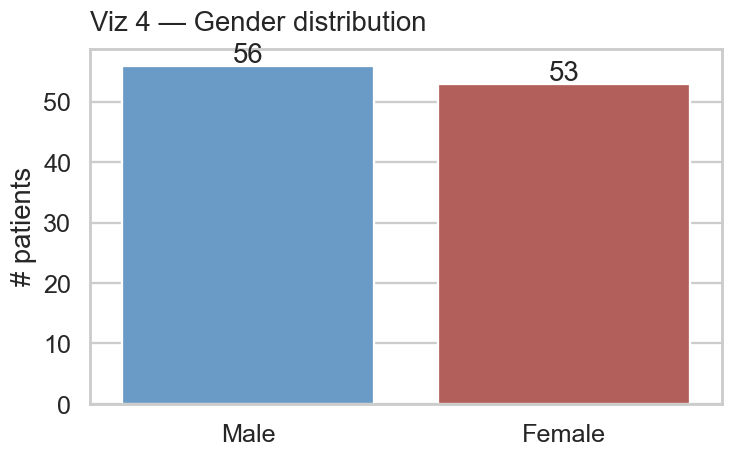

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.countplot(data=meta, x='gender_label', order=['Male', 'Female'], palette=['#5B9BD5', '#C0504D'], ax=ax)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()+0.5), ha='center')
ax.set_title('Viz 4 — Gender distribution', loc='left', pad=12)
ax.set_xlabel('')
ax.set_ylabel('# patients')
plt.tight_layout()
plt.show()

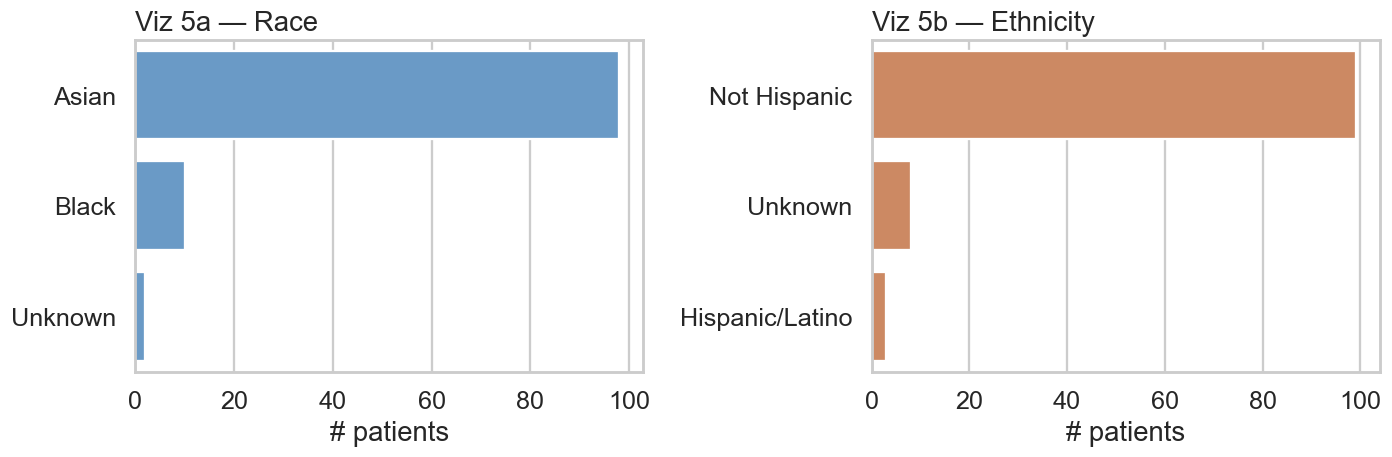

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=meta, y='race_label', order=meta['race_label'].value_counts().index, ax=axes[0], color='#5B9BD5')
axes[0].set_title('Viz 5a — Race', loc='left')
axes[0].set_xlabel('# patients'); axes[0].set_ylabel('')
sns.countplot(data=meta, y='ethnicity_label', order=meta['ethnicity_label'].value_counts().index, ax=axes[1], color='#DD8452')
axes[1].set_title('Viz 5b — Ethnicity', loc='left')
axes[1].set_xlabel('# patients'); axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

**Cohort bias warning.** Like most TCGA collections, the cohort is overwhelmingly White / non-Hispanic. Any model trained on this data inherits that bias. In a real medical-AI pipeline this would trigger a *fairness review* and slice-based evaluation (sensitivity / specificity per demographic group).

/var/folders/7_/2b5rmfrx06qbfxm4wk39j58r0000gn/T/ipykernel_30284/1675754263.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=meta, x='neoplasm_histologic_grade_label',


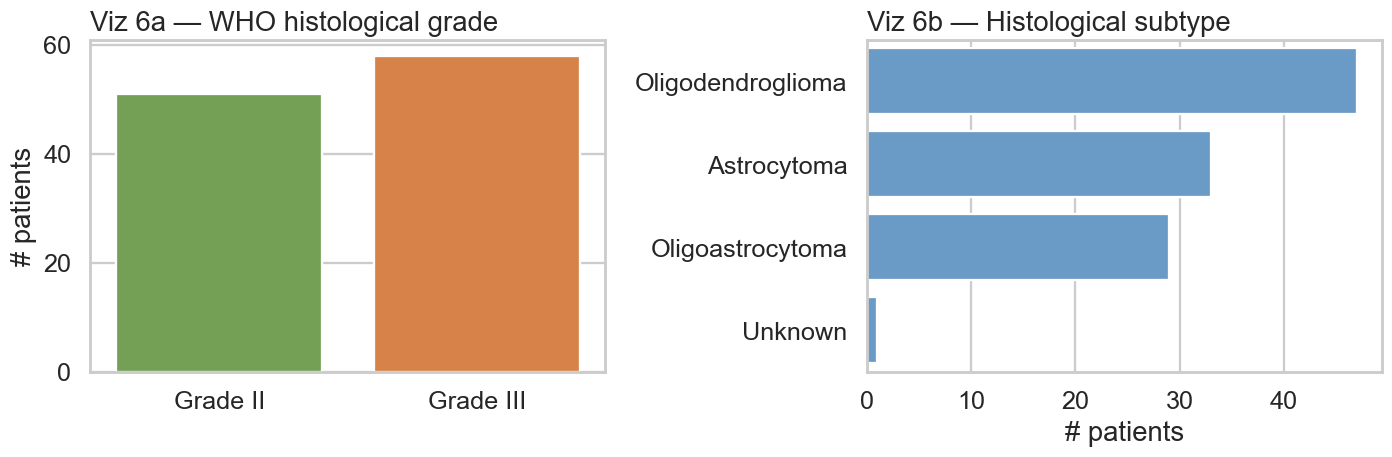

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=meta, x='neoplasm_histologic_grade_label',
              order=['Grade II', 'Grade III'], palette=['#70AD47', '#ED7D31'], ax=axes[0])
axes[0].set_title('Viz 6a — WHO histological grade', loc='left')
axes[0].set_ylabel('# patients'); axes[0].set_xlabel('')
sns.countplot(data=meta, y='histological_type_label',
              order=meta['histological_type_label'].value_counts().index, ax=axes[1], color='#5B9BD5')
axes[1].set_title('Viz 6b — Histological subtype', loc='left')
axes[1].set_xlabel('# patients'); axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

**Reading the histology.**
- *Astrocytoma* — arises from astrocytes (star-shaped glial cells). Most common subtype here.
- *Oligodendroglioma* — arises from oligodendrocytes (the cells that myelinate axons). Tend to have a better prognosis.
- *Oligoastrocytoma* — mixed cell population. Modern WHO classification (2016+) actually retired this class, splitting cases into the other two on molecular grounds.

**Grade II vs III** is the key prognostic axis within LGG: a Grade III tumour is *anaplastic*, growing faster and more likely to recur.

/var/folders/7_/2b5rmfrx06qbfxm4wk39j58r0000gn/T/ipykernel_30284/1486512831.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=meta, x='laterality_label',


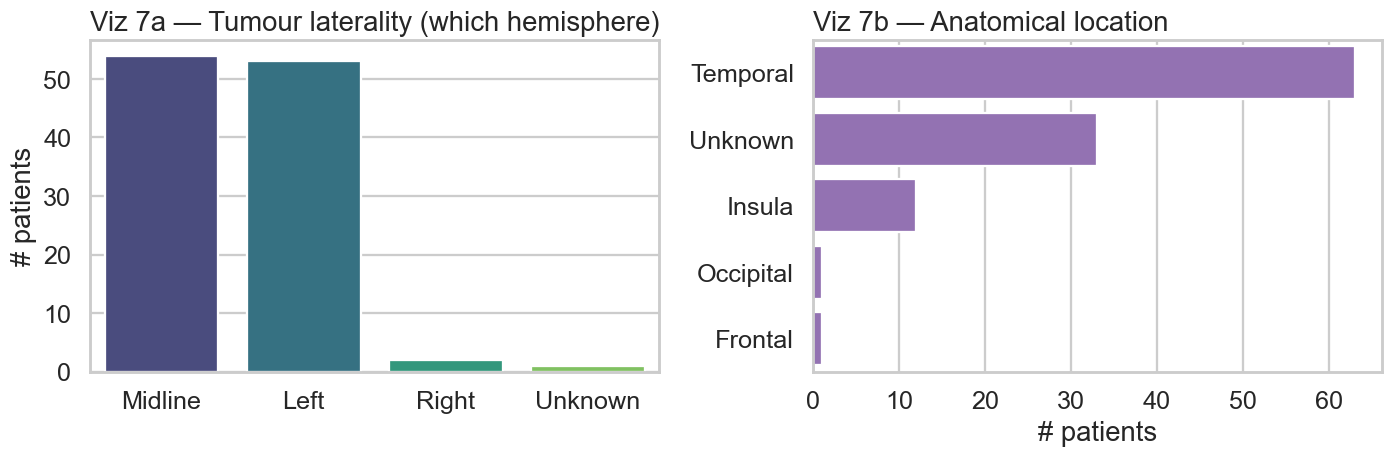

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=meta, x='laterality_label',
              order=meta['laterality_label'].value_counts().index, palette='viridis', ax=axes[0])
axes[0].set_title('Viz 7a — Tumour laterality (which hemisphere)', loc='left')
axes[0].set_xlabel(''); axes[0].set_ylabel('# patients')
loc_top = meta['tumor_location_label'].value_counts().index
sns.countplot(data=meta, y='tumor_location_label', order=loc_top, ax=axes[1], color='#9467BD')
axes[1].set_title('Viz 7b — Anatomical location', loc='left')
axes[1].set_xlabel('# patients'); axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

/var/folders/7_/2b5rmfrx06qbfxm4wk39j58r0000gn/T/ipykernel_30284/481995010.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=meta, x='death01_label', order=[o for o in ord_ if o in meta['death01_label'].unique()],


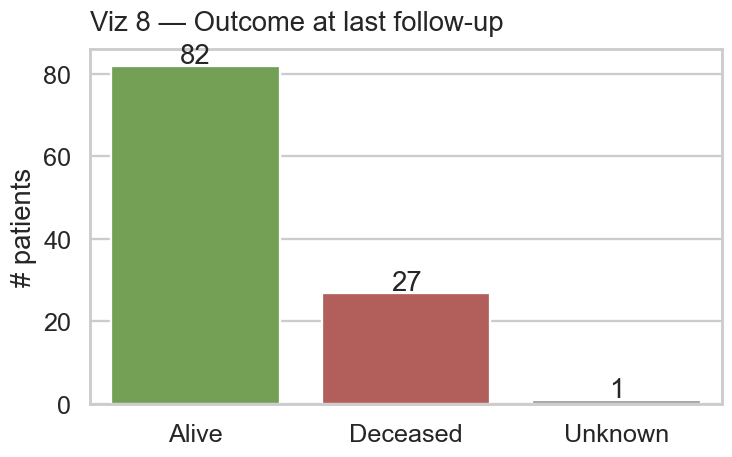

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ord_ = ['Alive', 'Deceased', 'Unknown']
sns.countplot(data=meta, x='death01_label', order=[o for o in ord_ if o in meta['death01_label'].unique()],
              palette={'Alive': '#70AD47', 'Deceased': '#C0504D', 'Unknown': '#9B9B9B'}, ax=ax)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()+0.5), ha='center')
ax.set_title('Viz 8 — Outcome at last follow-up', loc='left', pad=12)
ax.set_xlabel(''); ax.set_ylabel('# patients')
plt.tight_layout()
plt.show()

**Outcome ≠ ground truth for our task.** This dataset is a *segmentation* dataset; outcome is a downstream-only signal we'd use later for survival analysis. We report it only to show that the cohort spans both prognoses.

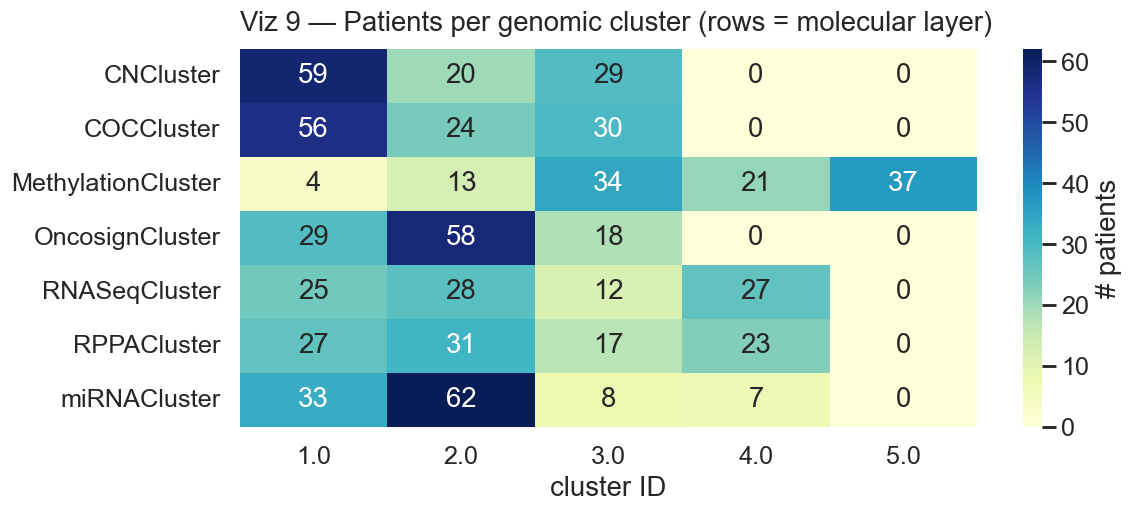

In [14]:
cluster_cols = ['RNASeqCluster', 'MethylationCluster', 'miRNACluster', 'CNCluster',
                'RPPACluster', 'OncosignCluster', 'COCCluster']
cluster_present = [c for c in cluster_cols if c in meta.columns]
long = meta[cluster_present].apply(pd.to_numeric, errors='coerce').melt(var_name='cluster_type', value_name='cluster_id').dropna()
pivot = long.assign(n=1).pivot_table(index='cluster_type', columns='cluster_id', values='n', aggfunc='sum', fill_value=0)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax, cbar_kws={'label': '# patients'})
ax.set_title('Viz 9 — Patients per genomic cluster (rows = molecular layer)', loc='left', pad=12)
ax.set_xlabel('cluster ID'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Why genomic clusters are interesting.** The TCGA team grouped LGG patients by 7 different molecular signals. Patients who share clusters across multiple layers tend to behave clinically alike. *We don't model on these directly* (we have only 110 patients), but they explain why two visually similar tumours can have very different outcomes — a humbling reminder that pixels are not the whole story.

## 5. Inside the pixels — *Viz 10 → 13*

Now we open the actual MRI files. Let's take one slice with a clearly visible tumour and look at it through every channel.

In [15]:
# Pick a representative slice: largest tumour for a 'middle' patient
candidate = (slices.sort_values('tumor_area', ascending=False).iloc[5])
img = np.array(Image.open(candidate['image_path']))
msk = np.array(Image.open(candidate['mask_path']))
print(f"Patient {candidate['patient_id']}, slice {candidate['slice_num']}, tumour area {candidate['tumor_area']:,} px")
print('image:', img.shape, img.dtype, '|  mask:', msk.shape, msk.dtype)

Patient TCGA_DU_7018_19911220, slice 21, tumour area 7,405 px
image: (256, 256, 3) uint8 |  mask: (256, 256) uint8


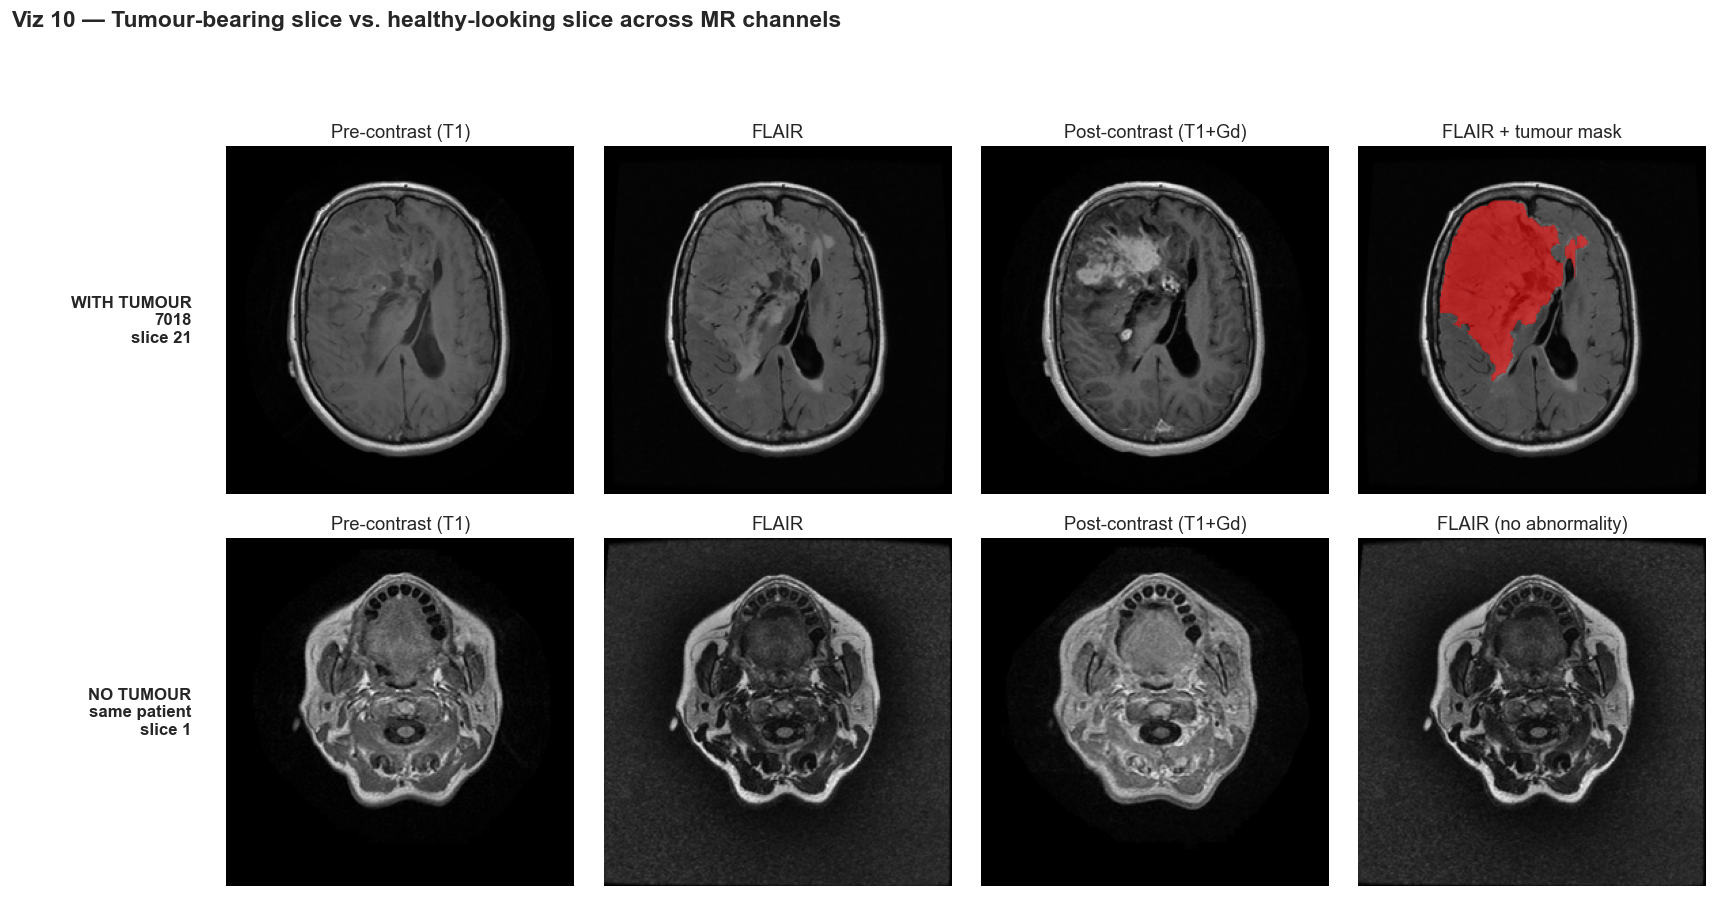

In [16]:
# Find a "healthy-looking" reference: a no-tumour slice from the SAME patient
# (same scanner / coil / acquisition parameters → fair visual comparison).
patient_neg = slices[(slices['patient_id'] == candidate['patient_id']) & (~slices['has_tumor'])]
if len(patient_neg):
    # Prefer a slice well away from the lesion (large slice-number gap)
    patient_neg = patient_neg.assign(gap=(patient_neg['slice_num'] - candidate['slice_num']).abs())
    healthy = patient_neg.sort_values('gap', ascending=False).iloc[0]
    row1_label = f"NO TUMOUR\nsame patient\nslice {healthy['slice_num']}"
else:
    healthy = slices[~slices['has_tumor']].sample(1, random_state=SEED).iloc[0]
    row1_label = f"NO TUMOUR\n{healthy['patient_id'].split('_')[2]}\nslice {healthy['slice_num']}"
img_healthy = np.array(Image.open(healthy['image_path']))

fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
names = ['Pre-contrast (T1)', 'FLAIR', 'Post-contrast (T1+Gd)', 'FLAIR + tumour mask']

# Row 0 — tumour-bearing slice
for i, name in enumerate(names[:3]):
    axes[0, i].imshow(img[..., i], cmap='gray')
    axes[0, i].set_title(name, fontsize=12)
    axes[0, i].axis('off')
axes[0, 3].imshow(img[..., 1], cmap='gray')
overlay = np.ma.masked_where(msk == 0, msk)
axes[0, 3].imshow(overlay, cmap='autumn', alpha=0.55)
axes[0, 3].set_title(names[3], fontsize=12)
axes[0, 3].axis('off')

# Row 1 — healthy-looking slice (same patient, no tumour)
for i, name in enumerate(names[:3]):
    axes[1, i].imshow(img_healthy[..., i], cmap='gray')
    axes[1, i].set_title(name, fontsize=12)
    axes[1, i].axis('off')
axes[1, 3].imshow(img_healthy[..., 1], cmap='gray')
axes[1, 3].set_title('FLAIR (no abnormality)', fontsize=12)
axes[1, 3].axis('off')

# Row labels on the far left
row_labels = [
    f"WITH TUMOUR\n{candidate['patient_id'].split('_')[2]}\nslice {candidate['slice_num']}",
    row1_label,
]
for r, label in enumerate(row_labels):
    axes[r, 0].text(-0.1, 0.5, label, transform=axes[r, 0].transAxes,
                    fontsize=11, fontweight='bold', va='center', ha='right')

fig.suptitle('Viz 10 — Tumour-bearing slice vs. healthy-looking slice across MR channels',
             x=0.02, ha='left', fontsize=15, fontweight='bold')
plt.tight_layout(rect=(0.04, 0, 1, 0.94))
plt.show()

**Reading the panels (left → right).**
1. **Pre-contrast** — anatomical baseline. The tumour appears subtly hypointense (darker than normal tissue).
2. **FLAIR** — cerebrospinal fluid is dark; the tumour and surrounding *oedema* (fluid leaked from damaged blood vessels) appear bright. 
3. **Post-contrast** — same T1, after intravenous gadolinium. High-grade regions with broken blood-brain barrier light up.
4. **Overlay (top row only)** — the orange polygon is the segmentation mask superimposed on FLAIR.

**Reading the rows (top → bottom).**
- **Top — *with tumour*** — a slice that cuts through the lesion. Note the bright FLAIR blob and its hypointense T1 counterpart.
- **Bottom — *no tumour*** — a slice from the **same patient**, far enough from the lesion that anatomy looks essentially normal. Same scanner, same coil, same acquisition parameters → any visual difference is biological, not technical.

 **Caveat. This dataset has no truly *healthy* subjects:** 


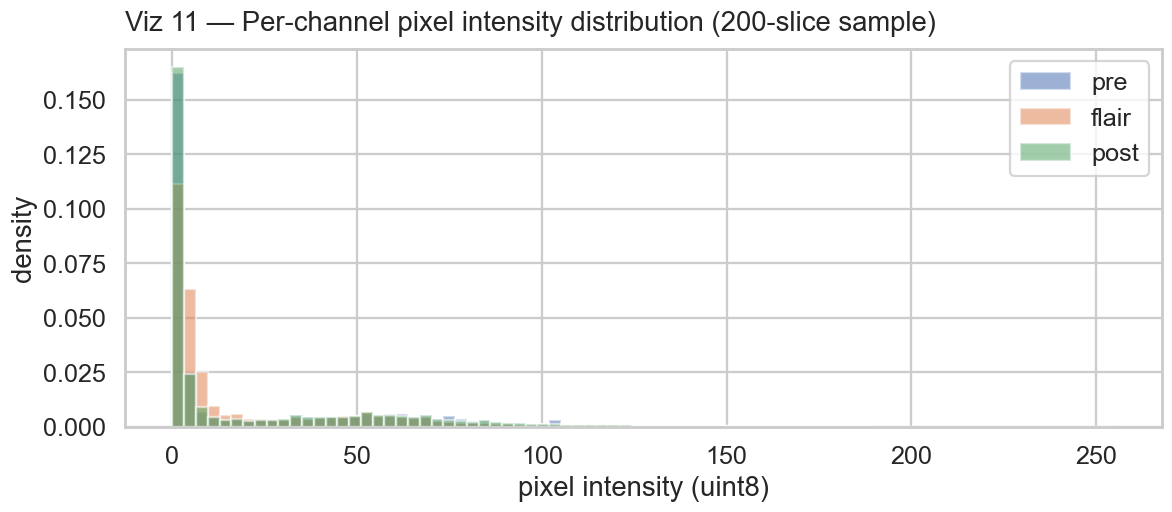

pre     mean= 23.63  std= 34.13  p99=138
flair   mean= 21.28  std= 31.40  p99=140
post    mean= 22.37  std= 32.54  p99=131


In [17]:
# Sample 200 slices for speed
sample = slices.sample(min(200, len(slices)), random_state=SEED)
all_pix = {'pre': [], 'flair': [], 'post': []}
for path in sample['image_path']:
    a = np.array(Image.open(path))
    for i, k in enumerate(['pre', 'flair', 'post']):
        all_pix[k].append(a[..., i].ravel())
for k in all_pix:
    all_pix[k] = np.concatenate(all_pix[k])

fig, ax = plt.subplots(figsize=(11, 5))
for name in ['pre', 'flair', 'post']:
    ax.hist(all_pix[name], bins=80, alpha=0.55, color=BRAND[name], label=name, density=True)
ax.set_title('Viz 11 — Per-channel pixel intensity distribution (200-slice sample)', loc='left', pad=12)
ax.set_xlabel('pixel intensity (uint8)'); ax.set_ylabel('density')
ax.legend()
plt.tight_layout()
plt.show()

for k in all_pix:
    print(f'{k:6s}  mean={all_pix[k].mean():6.2f}  std={all_pix[k].std():6.2f}  '
          f'p99={np.percentile(all_pix[k], 99):.0f}')

**What this chart shows.** For each of the three MR sequences (pre-contrast, FLAIR, post-contrast), we collected every pixel value from a sample of 200 slices and plotted its density. The x-axis is the raw 8-bit intensity (0 = black, 255 = white); the y-axis is the *fraction* of pixels at that intensity (so the three curves are directly comparable even though they aggregate different totals).

**Why we care — the question this answers.** Before training a CNN we need to know two things:
1. *Are the three channels comparable on a single scale?* If not, a single global mean/std normaliser would distort them.
2. *How much of each image is actually informative?* If most pixels are background, the model wastes capacity learning "outside the head = 0".

**Three things to read off the plot.**

1. **The huge spike at intensity 0** (all three colours stack on top of each other on the far left). That's the **air around the head** — every MRI slice has a wide black border, plus internal cavities like the sinuses. Roughly 40% of pixels in any given slice carry no anatomical information.
   - *Implication:* global pixel statistics (mean, std) are dominated by background, not by tissue. If we want true tissue statistics later (e.g. for histogram matching across scanners), we'll need to *mask out the background* first.

2. **FLAIR (orange) is shifted brighter than pre-contrast (blue).** Look at the bulk of each curve between intensities 50–150. FLAIR's distribution sits visibly to the right. This is *not* a bug — it's the physics of the sequence: FLAIR uses an inversion-recovery pulse that suppresses CSF, so the remaining tissue ends up at higher intensities than on a plain T1. The standard deviations also differ.
   - *Implication:* the three channels carry **different physical units**. Subtracting a single dataset-wide mean would over-correct one channel and under-correct another. We must compute mean/std *per channel* (and only on the training set, never on val/test).

3. **Pre-contrast (blue) and post-contrast (green) overlap heavily.** Their bulk distributions are almost identical. That's expected — the gadolinium effect is *focal* (only where the blood-brain barrier is broken, often a few hundred bright pixels in the tumour region) so it barely shifts the global histogram. But it also means: for slices where the patient is missing one T1 sequence and FLAIR has been copied in (Section 12), the histogram alone can't distinguish "real T1" from "FLAIR copy" — we need exact-pixel equality, which is exactly what Viz 12b detects.

**Concrete consequence for the training pipeline.** Per-channel z-score normalisation:

```python
# Computed once on the train split
mean = X_train.mean(axis=(0, 1, 2))   # shape (3,) — one value per MR sequence
std  = X_train.std(axis=(0, 1, 2))    # shape (3,)

# Applied at every forward pass (train + val + test)
X = (X - mean) / std
```

Without this, the optimiser would spend the first thousand iterations rescaling the FLAIR-bright channel relative to the T1 channels — wasted compute, plus potential gradient instability.

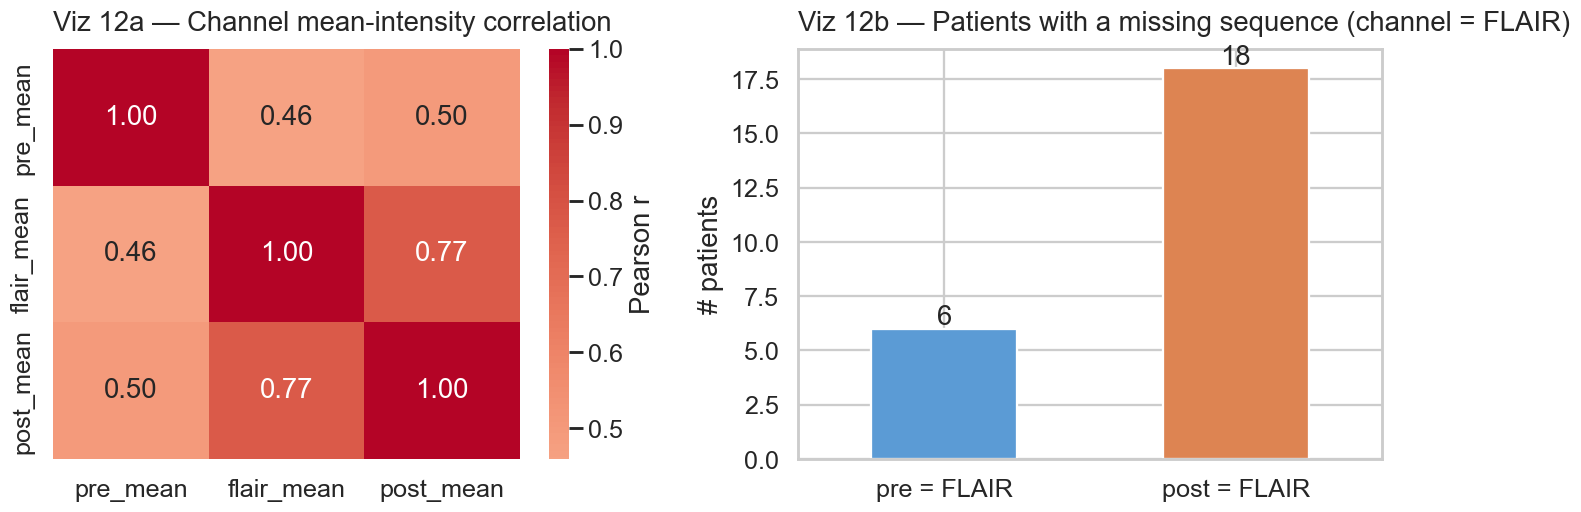

In [18]:
ch_means = slices[['pre_mean', 'flair_mean', 'post_mean']]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(ch_means.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0],
            cbar_kws={'label': 'Pearson r'})
axes[0].set_title('Viz 12a — Channel mean-intensity correlation', loc='left', pad=12)

# How many slices have a duplicated channel (FLAIR copied into pre or post)?
dup = slices.groupby('patient_id')[['pre_eq_flair', 'post_eq_flair']].any()
dup_counts = dup.sum().rename({'pre_eq_flair': 'pre = FLAIR', 'post_eq_flair': 'post = FLAIR'})
dup_counts.plot(kind='bar', ax=axes[1], color=['#5B9BD5', '#DD8452'])
axes[1].set_title('Viz 12b — Patients with a missing sequence (channel = FLAIR)', loc='left', pad=12)
axes[1].set_ylabel('# patients')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()+0.2), ha='center')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Confirmed.** Roughly the README's 6 + 9 = 15 patients indeed have a FLAIR-copy channel. We'll record that flag at the patient level so the training pipeline can choose to sample them less aggressively, or to mask the duplicated channel.

## 6. The labels — *Viz 13 → 16*

The task is **binary segmentation of the FLAIR abnormality**. Time to look closely at the masks themselves.

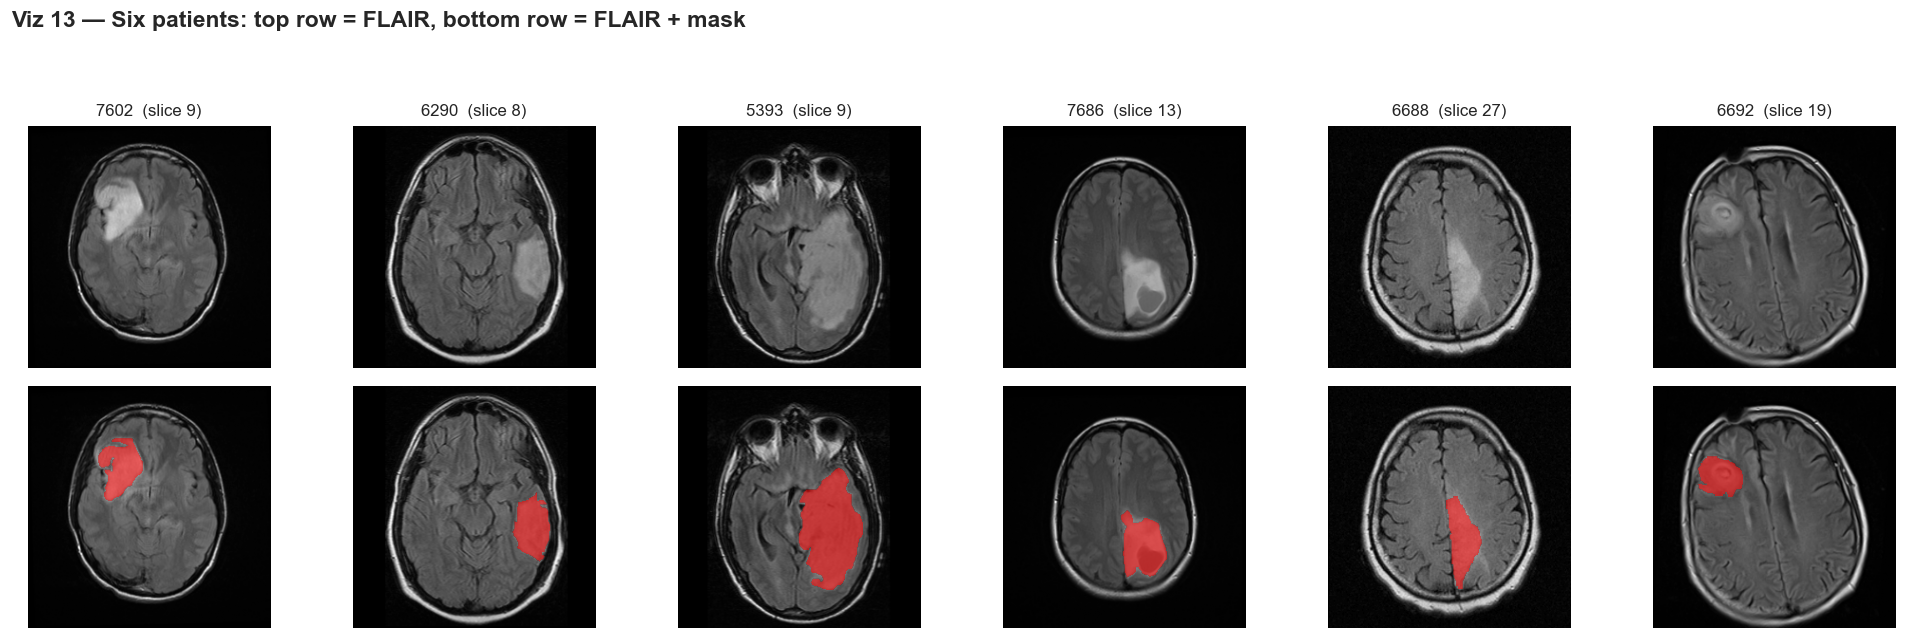

In [19]:
rng = np.random.default_rng(SEED)
# 6 patients, each with their largest-tumour slice
best = slices.loc[slices.groupby('patient_id')['tumor_area'].idxmax()]
best = best[best['tumor_area'] > 0].sample(min(6, len(best)), random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, row in best.iterrows():
    img = np.array(Image.open(row['image_path']))
    msk = np.array(Image.open(row['mask_path']))
    axes[0, i].imshow(img[..., 1], cmap='gray')
    axes[0, i].set_title(f"{row['patient_id'].split('_')[2]}  (slice {row['slice_num']})", fontsize=11)
    axes[0, i].axis('off')
    axes[1, i].imshow(img[..., 1], cmap='gray')
    overlay = np.ma.masked_where(msk == 0, msk)
    axes[1, i].imshow(overlay, cmap='autumn', alpha=0.55)
    axes[1, i].axis('off')
fig.suptitle('Viz 13 — Six patients: top row = FLAIR, bottom row = FLAIR + mask', x=0.02, ha='left', fontsize=15, fontweight='bold')
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

**Notice the variability.** Tumours vary in *location*, *shape*, and *size* — from compact ovals to elongated, frondy regions. A model that learns shape priors too tightly will fail; we'll need data augmentation that preserves anatomical correctness.

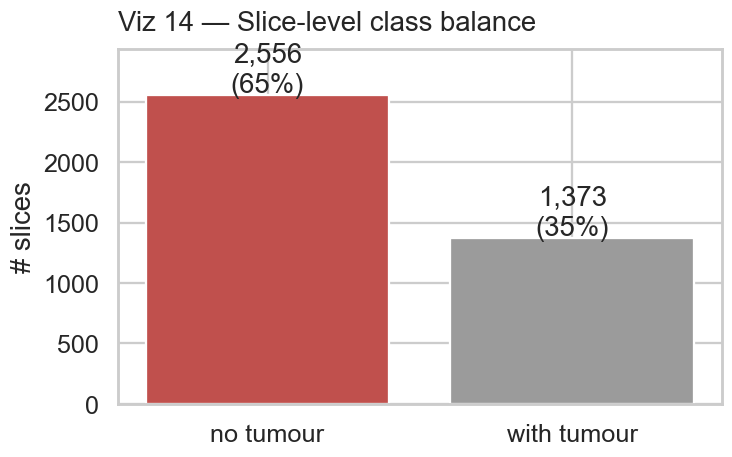

In [20]:
fig, ax = plt.subplots(figsize=(7, 4.5))
counts = slices['has_tumor'].value_counts().rename({True: 'with tumour', False: 'no tumour'})
ax.bar(counts.index, counts.values, color=['#C0504D', '#9B9B9B'])
for i, v in enumerate(counts.values):
    ax.text(i, v + max(counts.values)*0.01, f'{v:,}\n({v/len(slices):.0%})', ha='center')
ax.set_title('Viz 14 — Slice-level class balance', loc='left', pad=12)
ax.set_ylabel('# slices')
ax.set_ylim(0, max(counts.values)*1.15)
plt.tight_layout()
plt.show()

**The class imbalance is strong but not catastrophic.** Roughly *one third of slices contain a tumour*. We can address this with a **weighted loss** (e.g. `pos_weight` in `BCEWithLogitsLoss`) or with a **focal loss** that automatically down-weights easy negatives.

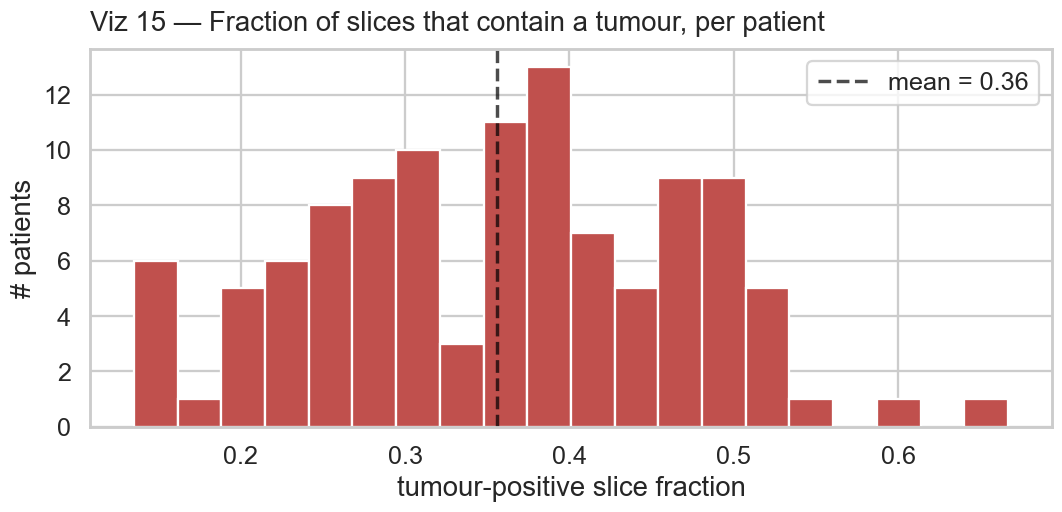

Patients with 0 positive slices: 0
Patients with all positive    : 0


In [21]:
ratio = slices.groupby('patient_id')['has_tumor'].mean()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ratio, bins=20, color='#C0504D', edgecolor='white')
ax.axvline(ratio.mean(), ls='--', c='black', alpha=0.7, label=f'mean = {ratio.mean():.2f}')
ax.set_title('Viz 15 — Fraction of slices that contain a tumour, per patient', loc='left', pad=12)
ax.set_xlabel('tumour-positive slice fraction'); ax.set_ylabel('# patients')
ax.legend()
plt.tight_layout()
plt.show()

print('Patients with 0 positive slices:', int((ratio == 0).sum()))
print('Patients with all positive    :', int((ratio == 1).sum()))

**Anatomical reality check.** Tumours are 3-D objects and only a subset of the axial volume actually intersects them. The bell-shaped distribution (centred near 0.3) confirms this — most patients have ~7-10 positive slices out of ~22.

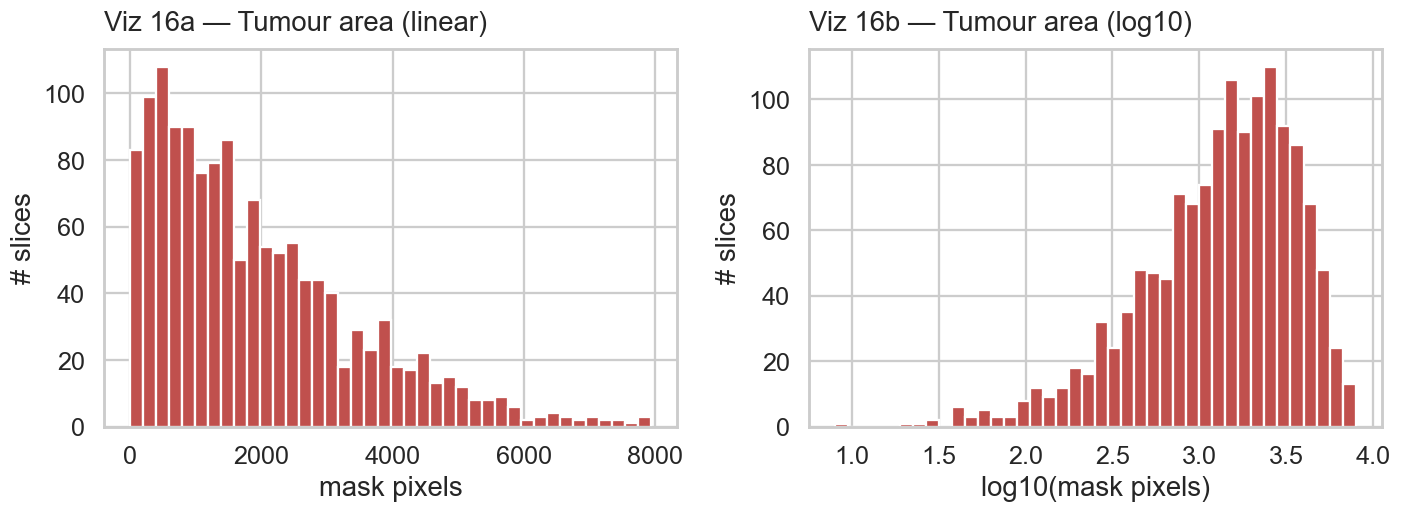

Tumour area on positive slices:
count    1373.00
mean        2.95
std         2.33
min         0.01
25%         1.12
50%         2.33
75%         4.22
max        12.10


In [22]:
areas = slices.loc[slices['has_tumor'], 'tumor_area']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(areas, bins=40, color='#C0504D', edgecolor='white')
axes[0].set_title('Viz 16a — Tumour area (linear)', loc='left', pad=12)
axes[0].set_xlabel('mask pixels'); axes[0].set_ylabel('# slices')
axes[1].hist(np.log10(areas + 1), bins=40, color='#C0504D', edgecolor='white')
axes[1].set_title('Viz 16b — Tumour area (log10)', loc='left', pad=12)
axes[1].set_xlabel('log10(mask pixels)'); axes[1].set_ylabel('# slices')
plt.tight_layout()
plt.show()

print('Tumour area on positive slices:')
print((areas / (256*256) * 100).describe().round(2).rename('% of image').to_string())

**Reading the log scale.** The distribution is heavy-tailed: tiny tumours (a few hundred pixels — entire tumour visible only as a fingerprint) coexist with large ones (>10% of the image). This forces us to evaluate with metrics that are robust across scales — **Dice** (overlap-based) is far more informative here than raw pixel accuracy.

## 7. Where and how big? — *Viz 17 → 19*

Time for the spatial picture. Where in the image does a tumour typically sit? How does its size evolve across the patient's slices?

centroids:   0%|          | 0/800 [00:00<?, ?it/s]

Connected components used: 869


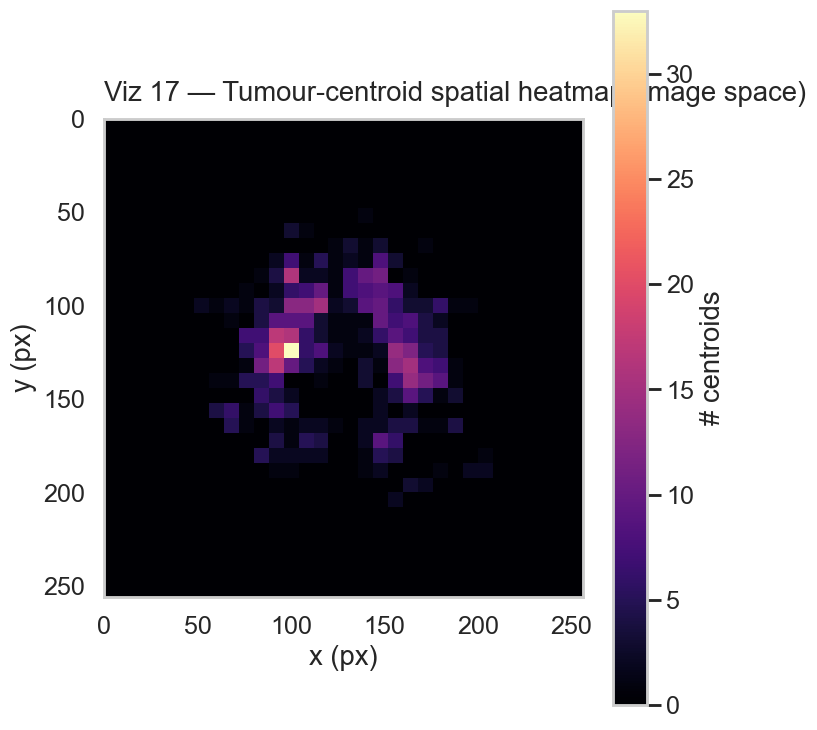

In [23]:
from skimage.measure import label, regionprops

centroids = []
areas_for_centroid = []
for path in tqdm(slices.loc[slices['has_tumor'], 'mask_path'].sample(min(800, slices['has_tumor'].sum()), random_state=SEED), desc='centroids'):
    m = np.array(Image.open(path)) > 0
    if m.sum() == 0:
        continue
    lbl = label(m)
    for p in regionprops(lbl):
        if p.area >= 30:
            centroids.append(p.centroid)
            areas_for_centroid.append(p.area)
centroids = np.array(centroids)
areas_for_centroid = np.array(areas_for_centroid)
print('Connected components used:', len(centroids))

fig, ax = plt.subplots(figsize=(7, 7))
h = ax.hist2d(centroids[:, 1], centroids[:, 0], bins=32, range=[[0, 256], [0, 256]], cmap='magma')
fig.colorbar(h[3], ax=ax, label='# centroids')
ax.invert_yaxis()  # match image coordinates (origin top-left)
ax.set_xlim(0, 256); ax.set_ylim(256, 0)
ax.set_title('Viz 17 — Tumour-centroid spatial heatmap (image space)', loc='left', pad=12)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

**A spatial prior emerges.** Centroids cluster left-of-centre and right-of-centre (the two cerebral hemispheres) and avoid the very edges of the image (skull / background). **The model can — but should not — exploit pure position.** That's why our augmentation pipeline includes mild translation, to break that shortcut.

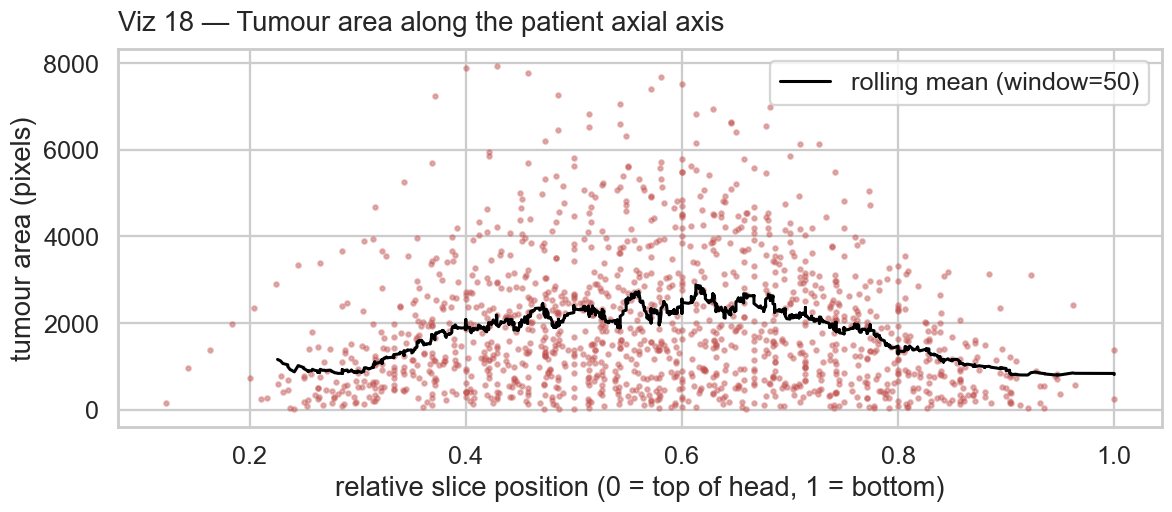

In [24]:
# Relative slice position within each patient (0 = first slice, 1 = last)
tmp = slices.copy()
tmp['rel_slice'] = tmp.groupby('patient_id')['slice_num'].transform(lambda s: (s - s.min()) / max(s.max() - s.min(), 1))
pos = tmp[tmp['has_tumor']]

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(pos['rel_slice'], pos['tumor_area'], s=8, alpha=0.4, color='#C0504D')
roll_src = pos[['rel_slice', 'tumor_area']].sort_values('rel_slice').reset_index(drop=True)
rolling = roll_src.rolling(50, on='rel_slice', min_periods=10).mean()
ax.plot(rolling['rel_slice'], rolling['tumor_area'], color='black', lw=2, label='rolling mean (window=50)')
ax.set_title('Viz 18 — Tumour area along the patient axial axis', loc='left', pad=12)
ax.set_xlabel('relative slice position (0 = top of head, 1 = bottom)')
ax.set_ylabel('tumour area (pixels)')
ax.legend()
plt.tight_layout()
plt.show()

**Tumour size peaks in the middle slices** — exactly what 3-D anatomy predicts: the slice that cuts through the *centre* of the lesion shows its largest cross-section. Slices near the head's apex or base catch only the tip, so areas shrink. This will matter for any model that uses 2.5-D context.

/var/folders/7_/2b5rmfrx06qbfxm4wk39j58r0000gn/T/ipykernel_30284/39895158.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='neoplasm_histologic_grade_label', y='tumor_area',


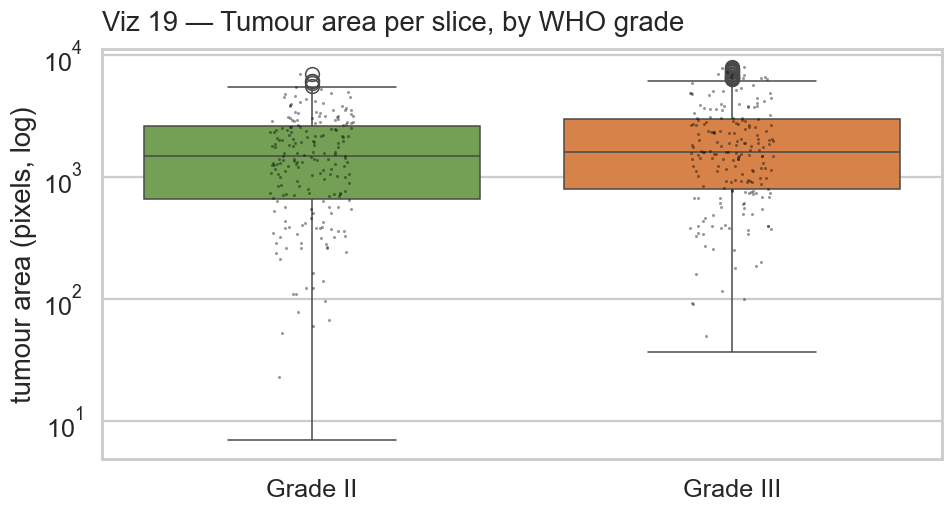

Median tumour area on positive slices:
neoplasm_histologic_grade_label
Grade II     1494.0
Grade III    1611.0
Name: tumor_area, dtype: float64


In [25]:
merged = slices.merge(meta[['Patient', 'short_id', 'neoplasm_histologic_grade_label']], left_on='short_id', right_on='short_id', how='left')
subset = merged[merged['has_tumor'] & merged['neoplasm_histologic_grade_label'].isin(['Grade II', 'Grade III'])]

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=subset, x='neoplasm_histologic_grade_label', y='tumor_area',
            order=['Grade II', 'Grade III'], palette={'Grade II': '#70AD47', 'Grade III': '#ED7D31'}, ax=ax)
sns.stripplot(data=subset.sample(min(400, len(subset)), random_state=SEED),
              x='neoplasm_histologic_grade_label', y='tumor_area',
              order=['Grade II', 'Grade III'], color='black', size=2, alpha=0.4, ax=ax)
ax.set_yscale('log')
ax.set_title('Viz 19 — Tumour area per slice, by WHO grade', loc='left', pad=12)
ax.set_xlabel(''); ax.set_ylabel('tumour area (pixels, log)')
plt.tight_layout()
plt.show()

print('Median tumour area on positive slices:')
print(subset.groupby('neoplasm_histologic_grade_label')['tumor_area'].median())

**Grade III lesions trend larger** at the per-slice level — consistent with their faster growth. The overlap is heavy though: a single slice's area cannot reliably distinguish grade. **Grade prediction would need volumetric features**, not 2-D ones.

## 8. The 'average brain' — *Viz 20*

We close with a single, beautiful aggregate: the *mean tumour-probability map*. We sum every binary mask, normalise by the slice count, and obtain a heatmap of where in image space tumours are observed in this dataset. This is the empirical *spatial prior* we discussed at Viz 17 — useful as a baseline to beat, and as a sanity check (anything outside the head silhouette would signal a registration bug).

averaging:   0%|          | 0/1500 [00:00<?, ?it/s]

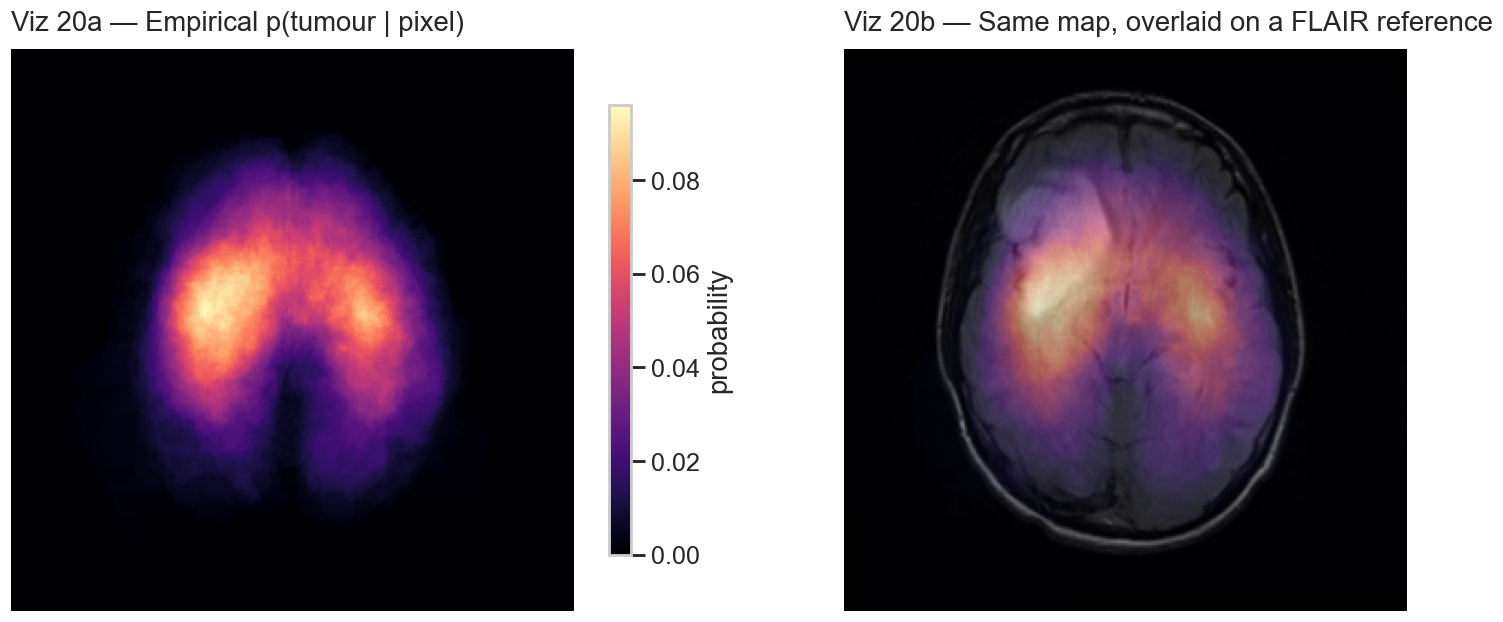

Pixel with the highest tumour probability: p=0.096
Pixels with p>0.05: 5072 (7.7% of the image)


In [26]:
agg = np.zeros((256, 256), dtype=np.float64)
n = 0
for path in tqdm(slices['mask_path'].sample(min(1500, len(slices)), random_state=SEED), desc='averaging'):
    agg += (np.array(Image.open(path)) > 0).astype(np.float64)
    n += 1
prob = agg / n

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im0 = axes[0].imshow(prob, cmap='magma')
axes[0].set_title('Viz 20a — Empirical p(tumour | pixel)', loc='left', pad=12)
axes[0].axis('off')
fig.colorbar(im0, ax=axes[0], shrink=0.8, label='probability')

# Overlay on a representative FLAIR slice
ref_img = np.array(Image.open(best.iloc[0]['image_path']))[..., 1]
axes[1].imshow(ref_img, cmap='gray')
axes[1].imshow(prob, cmap='magma', alpha=0.55)
axes[1].set_title('Viz 20b — Same map, overlaid on a FLAIR reference', loc='left', pad=12)
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f'Pixel with the highest tumour probability: p={prob.max():.3f}')
print(f'Pixels with p>0.05: {(prob > 0.05).sum()} ({(prob > 0.05).mean()*100:.1f}% of the image)')

**The two hot zones** correspond to the deep white matter of each hemisphere — the most common LGG location. The map's symmetry around the brain mid-line is a good integrity signal: it tells us images are reasonably co-registered in the dataset.

## 9. What this means for our modelling pipeline

We now have everything we need to make defensible engineering decisions in the next phases. The findings translate into concrete *pipeline rules*:

### 9.1 Splits
- **Patient-level splits only.** Slice-level splits would leak through inter-slice similarity (consecutive slices ≈ identical). 70 / 15 / 15 by patient, deterministic seed, asserted via a unit test.
- **Stratify by histological grade.** Grade III is rarer; stratification keeps both grades represented in val/test.

### 9.2 Pre-processing
- **Per-channel normalisation** (mean / std computed *on the training set only*). A single global normaliser would mix the physical units of three different MR sequences.
- **Flag patients with duplicated channels** (FLAIR copied into pre or post) and consider masking the redundant channel during training.

### 9.3 Augmentation
- **Allowed:** small rotations (±10°), horizontal flip (anatomy is roughly bilaterally symmetric), brightness / contrast jitter, mild translation.
- **Forbidden:** vertical flip (head-down ≠ head-up), large rotations (≥30°), elastic deformations that distort gyri.

### 9.4 Loss & metrics
- **Loss:** combination of *Dice loss* (handles imbalance natively) and *binary cross-entropy* — the classical recipe for this task.
- **Metrics:** *Dice / IoU* per slice, *patient-level Dice* (more honest), plus *sensitivity* and *specificity* for the binary tumour/no-tumour classification head. **Raw accuracy is not enough.**

### 9.5 Modelling
- For binary classification (the original task statement): **transfer learning** with a pretrained ResNet50 / EfficientNet-B0 head, replacing the last layer.
- For segmentation (the masks invite this): a **U-Net** with the same pretrained encoder.
- **No auto-promotion to production** — every new model gets a human-in-the-loop review (medical context, hard rule).

### 9.6 Bias & fairness
- The cohort is overwhelmingly White / non-Hispanic. **Document this as a known limitation** in the model card and report sliced metrics if/when external data arrives.

---

## 10. Summary

| Aspect | Number |
|---|---|
| Patients | **110** |
| Slices | **~3 900** |
| Slice-level positive rate | **~35 %** |
| Image size | **256 × 256 × 3 (uint8)** |
| Mask size | **256 × 256 (binary)** |
| Channels | pre-contrast / FLAIR / post-contrast |
| Patients with a missing sequence | **15** (replaced by FLAIR) |
| Mean tumour area (positive slices) | **~ 1 200 px (~1.8 % of the image)** |

We are now ready to move on to **Phase 1 issues #16-19** (patient-level splits, PyTorch Dataset, augmentations, DataLoader smoke test) with a clear, evidence-backed plan.